## Import libraries


In [1]:
import os
from glob import glob

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

CROP = "winter_wheat"

## Read the data


In [2]:
# Read the shapefile of Germany
de_nuts1_gdf = gpd.read_file(
    os.path.join("/beegfs", "halder", "DATA", "DE_NUTS", "DE_NUTS_3.shp")
)
de_nuts1_gdf = de_nuts1_gdf[
    de_nuts1_gdf["LEVL_CODE"] == 1
]  # filter only NUTS1 level code
de_nuts1_gdf = de_nuts1_gdf[["NUTS_NAME", "geometry"]]
de_nuts1_gdf.rename(columns={"NUTS_NAME": "STATE_NAME"}, inplace=True)
de_nuts1_gdf.to_crs(crs="EPSG:25832", inplace=True)

print(de_nuts1_gdf.shape)
de_nuts1_gdf.head()

(16, 2)


,STATE_NAME,geometry
438,Schleswig-Holstein,"MULTIPOLYGON (((647136.269 6037210.901, 647954..."
439,Mecklenburg-Vorpommern,"MULTIPOLYGON (((746439.633 6039257.434, 749642..."
440,Thüringen,"POLYGON ((623559.162 5722734.464, 624893.036 5..."
441,Niedersachsen,"MULTIPOLYGON (((479225.624 5970766.611, 479712..."
442,Baden-Württemberg,"MULTIPOLYGON (((546793.49 5514433.543, 546531...."


## Process the crop type samples


<Axes: >

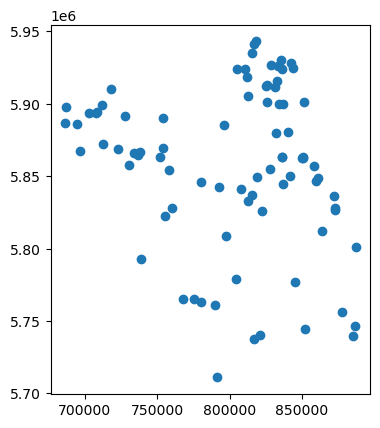

In [3]:
crop_type_samples = gpd.read_file(
    "/beegfs/halder/GITHUB/RESEARCH/soil-melioration-scenarios/data/processed/crop_type_samples/crop_type_samples.gpkg"
)
crop_type_samples["crop_type"] = crop_type_samples["crop_type"].replace(
    {
        "Wheat": "winter_wheat",
        "Barley": "winter_barley",
        "Potatoes": "potato",
        "Sugar Beet": "sugar_beet",
        "Rapeseed": "winter_rapeseed",
        "Maize": "grain_maize",
    }
)
crop_type_samples.to_crs(crs="EPSG:25832", inplace=True)

# Filter the points for Berlin and Brandenburg
crop_type_brandenburg = gpd.sjoin(
    left_df=crop_type_samples,
    right_df=de_nuts1_gdf[de_nuts1_gdf["STATE_NAME"].isin(["Berlin", "Brandenburg"])],
    predicate="within",
)
crop_type_brandenburg = crop_type_brandenburg[
    crop_type_brandenburg["crop_type"] == CROP
]
crop_type_brandenburg.plot()

In [4]:
# Print the data point per year
crop_type_brandenburg["year"].value_counts()

year
2017    21
2018    18
2020    18
2019    16
2021    12
Name: count, dtype: int64

## Process the LAI data


In [5]:
lai_file_paths = glob(
    "/beegfs/halder/GITHUB/RESEARCH/soil-melioration-scenarios/data/processed/crop_type_samples/LAI/*.csv"
)

lai_df_final = pd.DataFrame()
for path in lai_file_paths:
    lai_df = pd.read_csv(path)
    lai_df = lai_df.melt(id_vars="date", var_name="point_id", value_name="LAI")
    lai_df_final = pd.concat((lai_df_final, lai_df), axis=0, ignore_index=True)

lai_df_final["point_id"] = lai_df_final["point_id"].astype(int)
lai_df_final["date"] = pd.to_datetime(lai_df_final["date"], format="%Y-%m-%d")
lai_df_final = lai_df_final[
    lai_df_final["point_id"].isin(crop_type_brandenburg["point_id"].unique())
]

# Save the data
lai_df_final.to_csv(f"LAI_{CROP}.csv", index=False)
print(lai_df_final.shape)
lai_df_final.head()

(3910, 3)


,date,point_id,LAI
368,2019-01-01,3494,0.6
369,2019-01-09,3494,0.6
370,2019-01-17,3494,0.6
371,2019-01-25,3494,0.6
372,2019-02-02,3494,0.5


## Plot the data


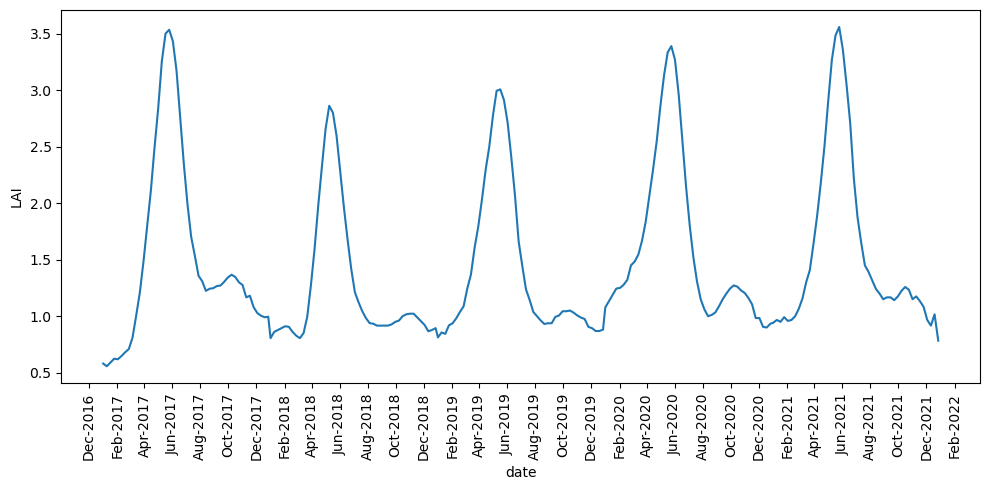

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=lai_df_final.groupby(by="date").mean(numeric_only=True).reset_index(),
    x="date",
    y="LAI",
    ax=ax,
)

# Show only Month-Year
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()